# 3D surface visualization for porous media using PyVista

Created by: Bernard Chang, Masa Prodanovic and James McClure

Updated: July 2022

Target audience: students and researchers wishing to visualize porous media data.

## Motivation

Segmented (also sometimes binary) images are those where each pixel or voxel has been classified as a member of a finite number of groups (phases, physical objects, elements or whatever is of interest to identify). We will here not spend more on the subject of segmentation (extremely important one!), but will use one such segmented image to plot surfaces between different phases (e.g. fluids, mineral phases in subsurface porous media) has already been made.

In 3D, it is very useful to draw surface that separates two phases or it is placed at an interpolated "level" of data. It is also called isosurface. Such surfaces in porous media are very complex, and consequently their 3D visualization (where what is shown is highly dependent on the viewer's position relative to the object being shown) is complex. For that reason, and due to constant software updates for pretty much anything, having a visualizer working is non-trivial. Jupyter notebooks, in addition, are attempting to add any visualization into the web-browser to seemlessly flow with the rest of the code and embedded Markdown text. Thus, if the images are not correctly embedded, using pyvista ina  regular Python environment is always an option. Just save this Notebook file (.ipynb) as a regular Python file (.py).

## Install PyVista + dependencies in a separate environment

You can skip this section if you have everything installed already.

### Create a Python (Anaconda) environment
Before you begin, I suggest you create a Python (Conda) environment with your 3D visualization
packages. If you are unfamiliar with these, a Conda environment is a directory that contains
specific Conda packages that you have installed. This helps prevent issues due to conflicting
dependency versions — such as if a dependency requires a certain version of a package but you
have already installed another version.
a) To set up a Conda environment, type the following in terminal or the Anaconda prompt:


conda create -n pyvista_nb anaconda

Conda will create an environment called “pyvista_nb” (feel free to change the name to
whatever you want) and install default anaconda packages.
PyVista requires Python version 3.6+

b) Activate the environment once it is finished installing the default Anaconda packages:

conda activate pyvista_nb

Some helpful documentation on Conda environments:
https://docs.conda.io/projects/conda/en/latest/user-guide/concepts/environments.html#
https://docs.conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html

### Install PyVista
After you activate the environment created above, let's  install pip in this environment and then isntall PyVista through pip inside this environment:

conda install pip

pip install pyvista

If pip does not work for some reason, alternate methods of installation can be found in the
PyVista documentation.
https://docs.pyvista.org/getting-started/installation.html

### Install packages to enable interactive plotting in Jupyter notebooks

Interactive plotting in Jupyter notebooks is enabled by installation of the following two possibilities. 

pip install pythreejs

pip install ipyvtklink

Note 1: pythreejs is missing support for some PyVista features like scalar bars and labels. You
could alternatively install ipyvtklink for full functionality, but interaction within the Jupyter
notebook is much slower.

Note 2: If none of them work for you, you can always use this notebook saved as a Python file in some classical Python environment that opens a separate window as opposed to trying to embed interactive visualization within a browser (as done by Jupyter Notebooks).

### How to use the new environment?
The new environment is separate from what you already had in Anaconda. Open Anaconda Navigator and click on "Environments" tab. You will see this environment on the list. Note that whatever else you need (like Jupyter Notebooks), you will need to install and run in this environment separately.

## Install Pyvista without the use of separate environment

Try all of the installation steps above within your existing, base Anaconda environment. You might want to update installed packages first:

conda update --all

before installation steps as follows:

pip install pyvista

pip install pythreejs

pip install ipyvtklink


## Import some useful packages


In [1]:
import requests # library for file download

import numpy as np
import skimage.transform

import matplotlib.pyplot as plt
import pyvista as pv

C:\Users\masha\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


## Useful functions for download and statistics

In [2]:
def download_file_url(file_url,filename):

    # download file
    r = requests.get(file_url, stream = True) 

    with open(filename,"wb") as f: 
        for chunk in r.iter_content(chunk_size=1024): 

             # writing one chunk at a time to pdf file 
             if chunk: 
                 f.write(chunk)
    return



def image_statistics(image, plot_histogram=False):
    print('\nImage (ndarray) shape',image.shape)
    print('\nImage data type',image.dtype)

    # This is a 2D image, and min, max and mean functions are programmed to work 
    # by dimension. 
    # So we will reshape the array. 
    # Be mindful that below we are on purpose creating another copy of the array 
    # (and doubles the memory use)
    dims = image.shape;
    reshaped_image = np.copy(image) 
    reshaped_image.shape = (np.prod(dims),)

    # min, max, mean are functions that are built into ndarray class in NumPy. 
    # If we call them such as in example below,
    # then they will execute on the ndarray reshaped_image
    print('\nImage values min:', reshaped_image.min(), 'max:',reshaped_image.max(), 'mean:',reshaped_image.mean())

    if plot_histogram:
        #Histogram
        # histogram has 256 bins, is normalized (density=True),
        # so that comparison with other images of different size is possible
        # and is shown in green color
        plt.hist(reshaped_image, 256, density=True, facecolor='g', alpha=0.75)

        plt.xlabel('Image value')
        plt.ylabel('Probability')

        #plt.axis([40, 160, 0, 0.03])
        plt.grid(True)
        plt.show()

    return

## Download and read example from DRP

We will download Digital Rocks Portal Example for the purpose from https://www.digitalrocksportal.org/projects/125/analysis_data/187/

In [8]:
# File download

#file_url = "https://www.digitalrocksportal.org/projects/125/images/101255/download/"
file_url = "/corral-repl/utexas/OTH21076/data_prod/published/DRP-125/Trapped oil in a Ketton limestone sample - Subset SSa/Ketton_rock_trapped_oil_Original_SSa/Ketton_rock_trapped_oil_Filtered_SSa"
file_url = "https://digitalporousmedia.org/published-datasets/tapis/projects/drp.project.published/drp.project.published.DRP-125/Trapped%20oil%20in%20a%20Ketton%20limestone%20sample%20-%20Subset%20SSa/Ketton_rock_trapped_oil_Original_SSa/Ketton_rock_trapped_oil_Filtered_SSa/"
file_url = "https://digitalporousmedia.org/published-datasets/tapis/projects/drp.project.published/drp.project.published.DRP-125/Trapped%20oil%20in%20a%20Ketton%20limestone%20sample%20-%20Subset%20SSa/Ketton_rock_trapped_oil_Original_SSa/Ketton_rock_trapped_oil_Filtered_SSa/Ketton_rock_trapped_oil_Filtered_SSa.raw"




# downloading once is enough, so you might want to comment the line below
download_file_url(file_url,filename)

In [7]:
# Read downloaded file and shape it into a 3D volume.

# the file is binary (.raw) file, 
# and requires information from the above webpage on how to read it.
width  = 365
height = 255
slices = 225

# Alternative
#dtype  = 'u1'
#byte = '<'  # little endian byte order
# read date from file
#datatype = byte + dtype    
alldata = np.fromfile(filename, dtype=np.ubyte, sep="")

image = alldata.reshape([slices, height, width])

In [8]:
print('Original image statistics\n')
image_statistics(image, plot_histogram=False)

# The original image is pretty large.
# Note - if I provide integer image below, then rescaling 
# shifts the image values even if I preserve_range (i.e. set it to True). 
# Hence I do a type conversion (image.astype(float))

# Likely culprit:
# Some online sites warn that skimage converts all floats to [-1,1]
# and many functions return float even if they get integer array as an input.
image_rescaled  = skimage.transform.rescale(image.astype(float), 0.5, preserve_range=True)

# check stats on rescaled image to make sure the values are preserved
image_statistics(image_rescaled, plot_histogram=False)

# resizing has the same trouble with integer array input, 
# so would have to use image.astype(float) conversion

#factor = 2
#image_resized = skimage.transform.resize(image,[width/factor,height/factor, slices/factor])
#image_statistics(image_resized,plot_histogram=False)

Original image statistics


Image (ndarray) shape (225, 255, 365)

Image data type uint8

Image values min: 1 max: 3 mean: 2.7589871967051662

Image (ndarray) shape (112, 128, 182)

Image data type float64

Image values min: 1.0 max: 3.0 mean: 2.758989161169739


### Matplotlib slice visualization

This is a quick check to see what a slice through our Ketton limestone image looks like.

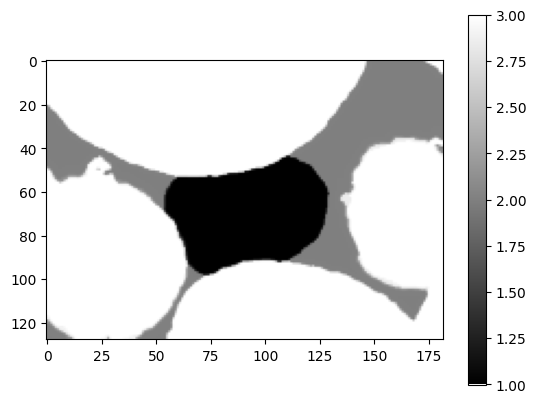

In [9]:
plt.imshow(image_rescaled[50,:,:], cmap='gray')
plt.colorbar()

## Interactive PyVista Visualization

Matplotlib visualizations are static but it is hard to guess a good angle to look at a complex data, and interactive plots are more helpful in that regard. 

Here, we will exemplify PyVista — an open-source, Python library that provides toolsets for interactive 3D Visualization and mesh analysis. Though there are several other available 3D visualization libraries (e.g. Vedo, Mayavi, Matplotlib, etc.), PyVista is currently stable across all computing platforms and provides relatively clear documentation.

Documentation:
https://docs.pyvista.org/

In [9]:
# Enable interactive plotting within a Jupyter notebook
# pythreejs is the smoothest that we have found (at this time), 
# but is missing some PyVista functionality
#
# ipyvtklink has all functionality, but is much slower
# If none of the backends work for interaction, you can use 'static' or export Python 
# file: executing regular Python script will open a separate window.
#pv.set_jupyter_backend('pythreejs')
pv.set_jupyter_backend('server')

# A function to initialize a PyVista Plotter Object
def initialize_plotter():
    
    # Initialize a PyVista Plotter Object
    plotter_obj = pv.Plotter()
    
    # Set the background color to white
    plotter_obj.set_background(color='w')
    pv.global_theme.font.color = 'black'
    
    return plotter_obj


# Wrap 3D NumPy array to PyVista data object
pv_img = pv.wrap(image_rescaled)

NameError: name 'image_rescaled' is not defined

#### Our first and simple PyVista plot
Here, we will create our first 3D plot in PyVista — a structured grid represented with markers (or "glyphs") that vary in size.

The workflow for creating any PyVista plot can be generalized as follows:

1. Make sure the data you want to plot is a PyVista data object. In this example, we use a built-in PyVista function ```StructuredGrid``` to create a PyVista data object. We used the wrap function in the cell above to convert a NumPy array into the PyVista data object. Depending on how your data is formatted to begin with (e.g. VTK object), you may need to find alternate methods of creating a PyVista data object.
    
2. Initialize a plotter object

3. Create a mesh for the data you wish to plot (e.g. orthogonal slices, isosurfaces, etc.) and add the mesh to the plotter object

4. Use the ```show()``` function to display the plot in a self-contained plotter 

In [11]:
# Create data
# a 1D array
n = 4 
x = np.linspace(1,n,n)

# structured grid of n x n x n points (i.e. 3D) dictated by 1D array x
X, Y, Z = np.meshgrid(x,x,x)
grid = pv.StructuredGrid(X,Y,Z)

# Create varying radii based on glyph coordinates
r = np.sqrt(X*X + Y*Y + Z*Z)

# Add glyph radii to structured grid data — takes in 1D array
grid["radius"] = r.ravel()

# Initialize PyVista plotter object
p = initialize_plotter()

# Create a vtk sphere mesh to be plotted
sphere = pv.Sphere(radius=0.05, phi_resolution=50, theta_resolution=50)

# Use the vtk sphere mesh as glyphs, scaling each sphere by the 
# previously calculated radii
sphere_points = grid.glyph(scale="radius", geom=sphere)

# Add the glyphs as a mesh to the plotter object
p.add_mesh(sphere_points, cmap='jet')

# Display the plot
p.show()


/Users/bchang/anaconda3/envs/agu24_workshop/lib/python3.12/site-packages/pyvista/core/filters/data_set.py:2386: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn("No vector-like data to use for orient. orient will be set to False.")


Widget(value='<iframe src="http://localhost:49766/index.html?ui=P_0x14b1742f0_0&reconnect=auto" class="pyvista…

## Plot orthogonal slice through the volume in PyVista

In [10]:
# A function that plots orthogonal slices through the 3D image
def plot_orthogonal_slices(pv_image_obj, x_slice, y_slice, z_slice):
    ################################################################################ 
    # Input: PyVista image object (wrapped NumPy array), x, y, and z slices to plot
    # Output: PyVista plot of orthogonal slices
    ################################################################################
    
    # Initialize the PyVista plotter object
    p = initialize_plotter()
    
    # Tests to make sure input slices are within image dimensions
    assert x_slice > 0 and x_slice < pv_image_obj.dimensions[0], "X-slice value outside image dimensions"
    assert y_slice > 0 and y_slice < pv_image_obj.dimensions[1], "Y-slice value outside image dimensions"
    assert z_slice > 0 and z_slice < pv_image_obj.dimensions[2], "Z-slice value outside image dimensions"
    
    # Create three orthogonal slices through the dataset at specified X, Y, and Z values
    slices = pv_image_obj.slice_orthogonal(x=x_slice, y=y_slice, z=z_slice)
    
    # Add the slices as meshes to the PyVista plotter object
    p.add_mesh(slices)
    
    # Display the plot
    p.show()


# Get dimensions of the rescaled image
x_dim, y_dim, z_dim = pv_img.dimensions

# Function call to plot the orthogonal slices.
plot_orthogonal_slices(pv_img, x_dim//2 , y_dim//2, z_dim//2)


NameError: name 'pv_img' is not defined

#### Oil blob surface

In the segmented image, we have 1, 2 and 3 represent oil, brine and rock respectively.

The interpolated value of 1.5 separated oil from everything else.

In [13]:
# Reinitialize plotter object
p = initialize_plotter()

# Generate a contoured surface at the explicitly specified isosurface value. 
oil_isosurface = pv_img.contour(isosurfaces=[1.5])

# Add the contoured surface as a mesh to the PyVista plotter object
# Color can be specified as a string (e.g. 'green'), RGB list, or hex color string
# Opacity is a single float value between 0 and 1 (inclusive). 
p.add_mesh(oil_isosurface, color=[0, 0.8, 0.27], opacity=1.)

# Display the plot
p.show()


Widget(value='<iframe src="http://localhost:49766/index.html?ui=P_0x16ac918b0_2&reconnect=auto" class="pyvista…

#### Pore-grain surface

Recall that the segmented image represents oil, brine and rock with values of 1, 2 and 3 respectively.
The surface passing through points where interpolated image values are 2.5 is a surface that separates both fluids and the rock. 



In [14]:
p = initialize_plotter()

# Generate a contoured surface at the explicitly specified isosurface value.
grain_isosurface = pv_img.contour(isosurfaces=[2.5])

# Add the contoured surface as a mesh to the PyVista plotter object
p.add_mesh(grain_isosurface, color=(153, 255, 255), opacity=0.8)

# Display the plot
p.show()

Widget(value='<iframe src="http://localhost:49766/index.html?ui=P_0x16ac45700_3&reconnect=auto" class="pyvista…

#### Oil blob and pore-grain surface together

To plot the oil blob and grain surface together (and any other phase that might be present), you can simply keep adding meshes to the same initial plotter object. 

In [16]:
# Reinitialize the Plotter object
p = initialize_plotter()

# Extract the oil surface contour and add the mesh to the Plotter object
oil_surface = pv_img.contour(isosurfaces=[1.5])
p.add_mesh(oil_surface, color=[0, 0.8, 0.27], opacity=0.5)

# Extract the grain surface contour and add the mesh to the Plotter object
grain_surface = pv_img.contour(isosurfaces=[2.5])
p.add_mesh(grain_surface, color=(153, 255, 255), opacity=0.5)

# Display the axes orientation widget (Will not show up if using pythreejs backend)
p.show_axes()

# Display the plot
p.show()

Widget(value='<iframe src="http://localhost:49766/index.html?ui=P_0x335e165d0_5&reconnect=auto" class="pyvista…

## Addendum 1: Matplotlib surface (elevation) plot
This is classical way to do 3D plots in Python shown here for reference. It always works because matplotlib is omnipresent, but the result is __not interactive__. For 3D data where visualization requires quite a bit of user input (there is no such thing as a default option working in most scientific 3D data visualization applications), this is barely adequate.

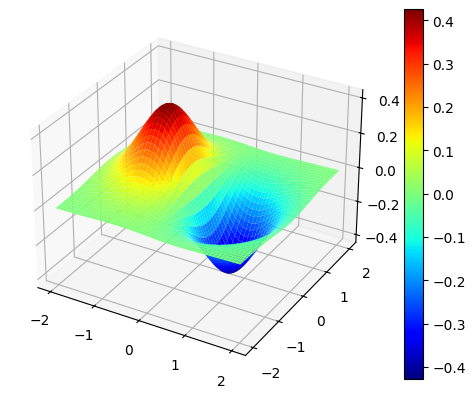

In [17]:
# 3D surface plot

# Create data for surface plot
# Native matplotlib image is static

import numpy as np
x=np.linspace(-2,2,100)
y = np.linspace(-2,2,100)
#print(x)
#print(y)

X,Y = np.meshgrid(x,y)
#print(X)
#print(Y)

Z = -X*(np.exp(- X**2 - Y**2))
#print(Z)

#First we plot it with matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure() #opens up empty figure

# tell the figure there will be a 3d projection
ax = fig.add_subplot(111,projection='3d')

# surface plot
surf = ax.plot_surface(X,Y,Z,cmap='jet')
# add colorbar
fig.colorbar(surf)

## Addendum 2: Interactive PyVista surface (elevation) plot

This example interprets 2D image data and warps it by scalar values (elevation). This is an interactive surface plot version of the previously shown matplotlib example in Addendum 1.

The PyVista data object to be plotted here is a StructuredGrid.

Documentation on Python scripting that visualizes structured surface data in PyVista:

https://docs.pyvista.org/examples/00-load/create-structured-surface.html?highlight=surface%20plot

In [18]:
# Make data
x=np.linspace(-2,2,500)
y = np.linspace(-2,2,500)
#print(x)
#print(y)

X,Y = np.meshgrid(x,y)
#print(X)
#print(Y)
Z = np.ones_like(X)
elevation = -X*(np.exp(- X**2 - Y**2))

# Create a structured grid
grid = pv.StructuredGrid(X, Y, Z)
# Add scalar to structured grid data for proper coloring — takes in 1D array. order='F' => Fortran-style ordering
grid['elevation'] = elevation.ravel(order='F')
# Warp operation modifies point coordinates by moving points along point normals by the scalar amount.
grid = grid.warp_by_scalar()

# Reinitialize plotter object
p = initialize_plotter()

# Add the structured grid as a mesh to the plotter object
p.add_mesh(grid, cmap='jet')

# Display the plot
p.show()



Widget(value='<iframe src="http://localhost:49766/index.html?ui=P_0x34b9989b0_6&reconnect=auto" class="pyvista…